Núcleos a calcular: 28   (L=0, beta_nl reducida = 0.2154–0.2160 fm, lambda 'after', vol.conserv.=False)

[1/28] 
>>> Fm-246 -> Z_hija=98, A_hija=242, Q=8.146 MeV, beta2=0.234, beta4=0.073, beta_nl=0.2160 fm
  [FT] densidad deformada (L = 0, 2, 4)... ok
  [V]  potenciales multipolares... ok
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (31.3 s)

Fm-246  (grupo A, β2=0.234, β4=0.073)   r3 Coulomb puro = 34.65 fm   β_nl = 0.2160 fm
Modelo         <lambda>     t1/2 (0°)    t1/2 (90°)   <Gamma> (MeV)   T1/2 <Gamma> (s)
--------------------------------------------------------------------------------------
DF               1.9145     1.963e-02     1.291e+00       2.372e-21          1.924e-01
Perey-Buck       2.2361     1.139e-02     8.036e-01       4.064e-21          1.123e-01
São Paulo        2.0356     1.313e-02     9.011e-01       3.541e-21          1.288e-01
Mumbai           1.9348     1.864e-02     1.210e+00       2.509e-21          1.818e-0

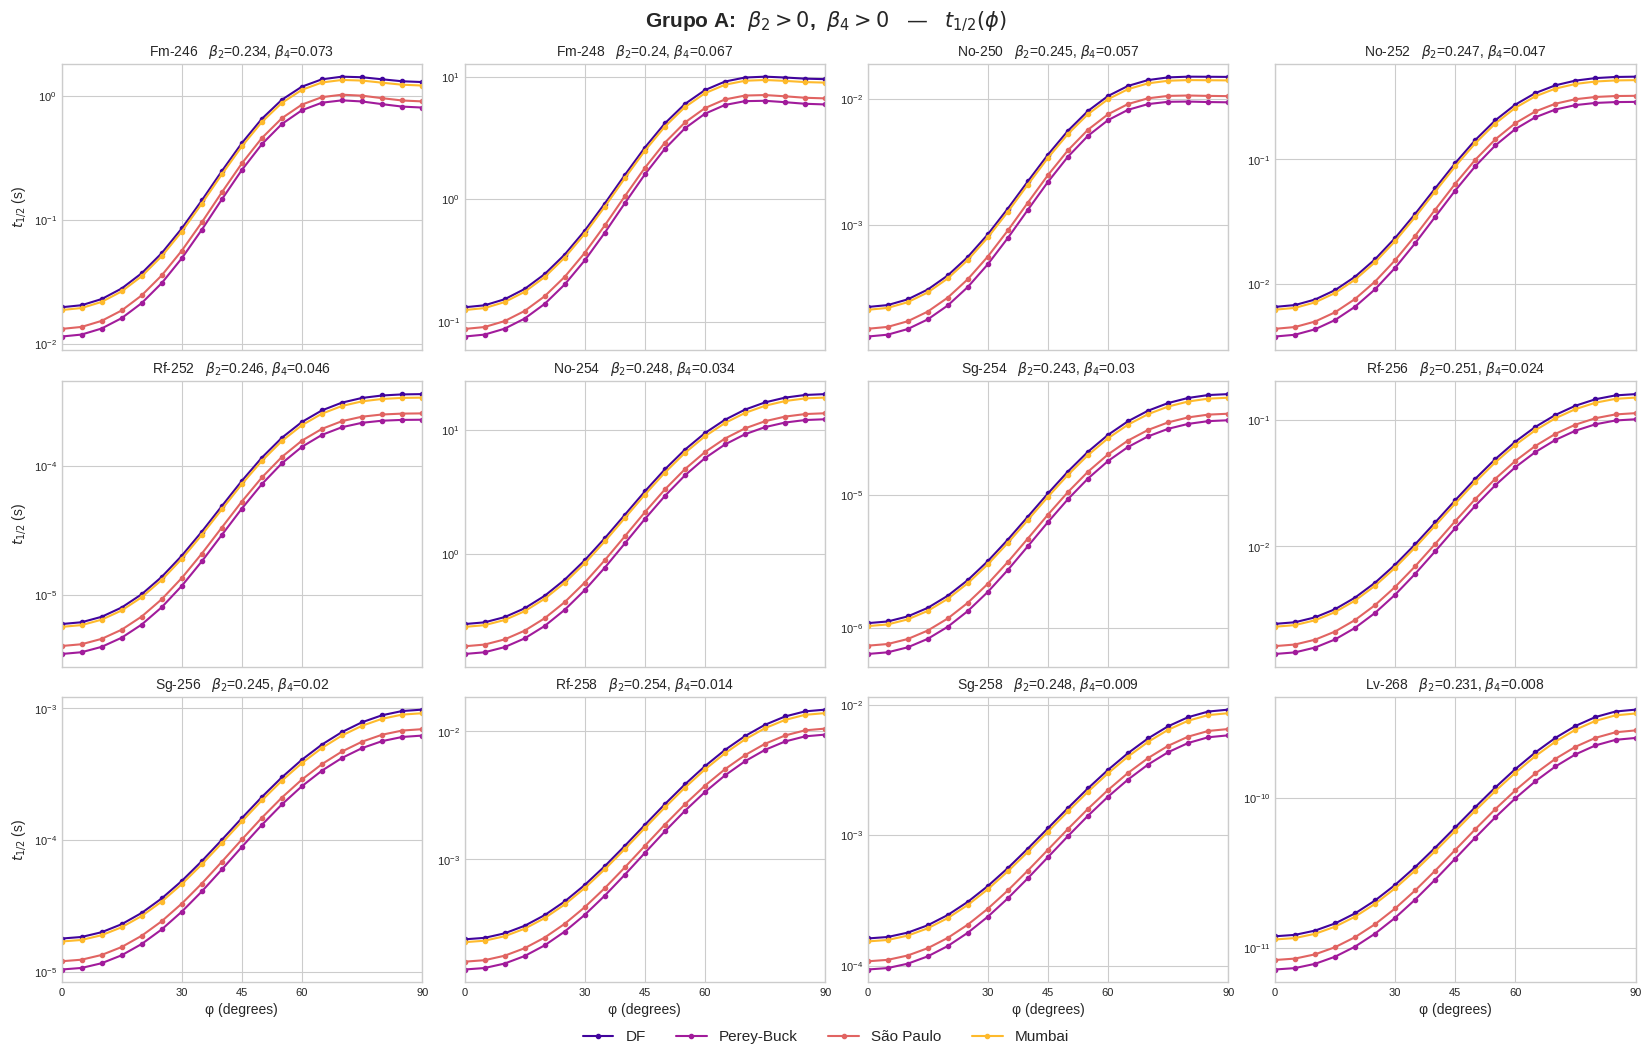

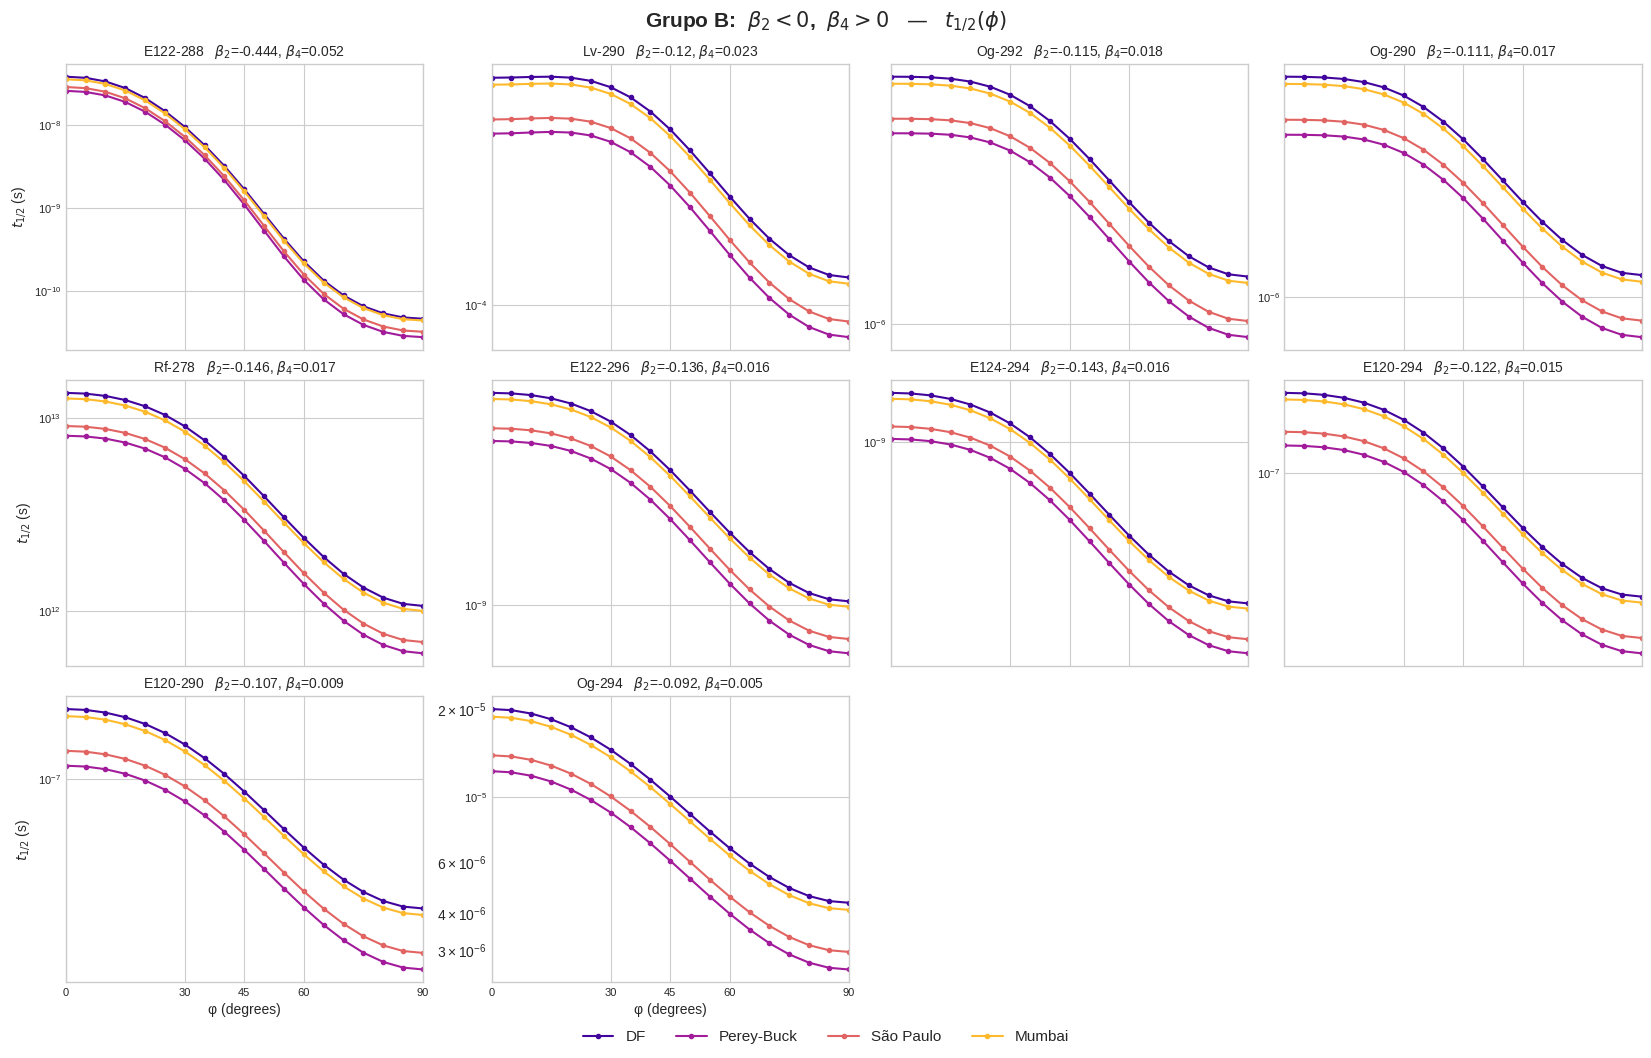

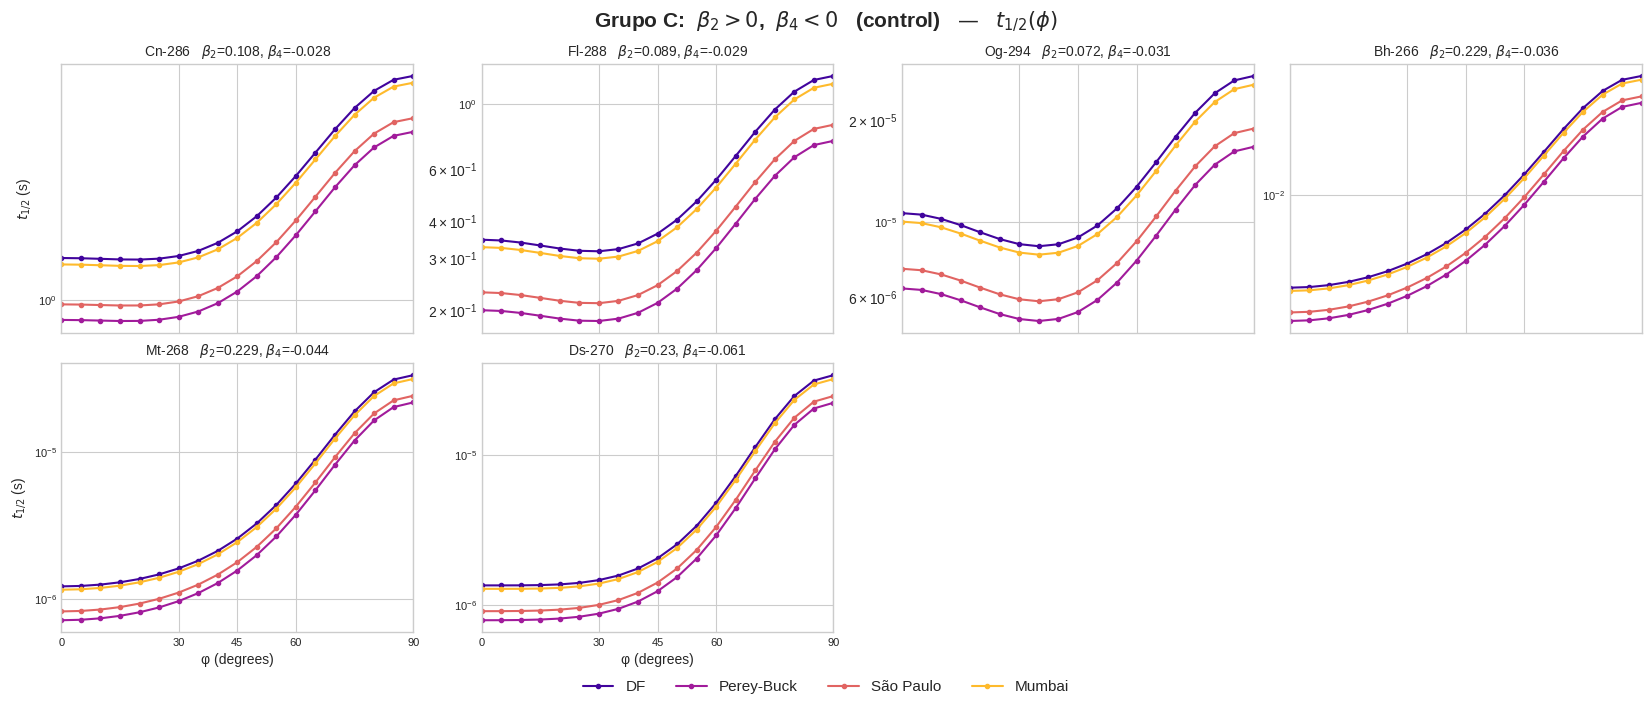

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa

          >>> VERSIÓN CON BUCLE SOBRE VARIOS NÚCLEOS SUPERPESADOS <<<

 Lo que es INDEPENDIENTE del núcleo vive a nivel de módulo (grillas, densidad
 de la alfa, armónicos).  Lo que DEPENDE del núcleo vive dentro de run_case().

 CAMBIO RESPECTO A LA VERSIÓN ANTERIOR
 -------------------------------------
 beta_nl ya no es una constante: ahora es la longitud de no-localidad REDUCIDA

        beta_nl(A_d) = 0.85 * (A_alpha + A_d) / (A_alpha * A_d)

 Como depende de la masa de la hija, el kernel de Mumbai deja de ser
 independiente del núcleo: se parametriza con bnl y se cachea por valor.
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CATÁLOGO DE NÚCLEOS
#  name  = núcleo PADRE (el emisor);  Z_d, A_d = hija
#  beta2, beta4 : Kowal, Jachimowicz & Skalski, arXiv:1203.5013 (Tabla 1)
#  Q            : teórico de esa misma tabla (sustituir por AME2020 si existe)
# ═════════════════════════════════════════════════════════════════════════════
NUCLEI = [
    # ---- A: beta2 > 0, beta4 > 0 ----
    dict(name="Cm-242", Z_d=82, Z_c=14, A_c=34, A_d=208, Q=96.509,  G=142, beta2=0, beta4=0, grupo="A"),
]

# Filtro rápido: None = todos.  Ej: SOLO_GRUPOS = ("A",)  /  SOLO_NOMBRES = ("No-254",)
SOLO_GRUPOS = None
SOLO_NOMBRES = None


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN GLOBAL
# ═════════════════════════════════════════════════════════════════════════════
LAMBDA_MODE = "after"      # "after" | "before"
MAKE_PLOTS = True          # una gráfica t1/2(phi) por núcleo
PLOT_RESUMEN = True        # gráfica comparativa final
TABLA_DETALLE = False      # True = imprime las 19 orientaciones de cada núcleo
VOLUME_CONSERVATION = False  # True = reescala R(theta) para conservar volumen

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0
N_U               = 64
N_PHI             = 19


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES (independientes del núcleo)
# ═════════════════════════════════════════════════════════════════════════════
e2       = 1.44
a_0      = 0.54
x_g      = 7999 / 4
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22
m_n      = 931.494
L        = 0            # g.s. -> g.s. entre par-par
BETA_NL0 = 0.85         # longitud de no-localidad "cruda" (fm)


def beta_nl_of(A_c,A_d):
    """
    No-localidad REDUCIDA para el sistema alfa + hija:

        beta_nl(A_d) = BETA_NL0 * (A_alpha + A_d) / (A_alpha * A_d)

    Depende del núcleo, por eso no puede ser una constante de módulo.
    """
    return BETA_NL0 * (A_c + A_d) / (A_c * A_d)


# ═════════════════════════════════════════════════════════════════════════════
#  ARMÓNICOS Y POLINOMIOS
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS (independientes del núcleo)
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)
PL  = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])

# NOTA: el chequeo "dR resuelve beta_nl?" se hace ahora dentro de run_case(),
# porque beta_nl depende de A_d.


# ═════════════════════════════════════════════════════════════════════════════
#  Dougther (esférica, analítica) e INTERACCIÓN NN  — no dependen del núcleo
# ═════════════════════════════════════════════════════════════════════════════
I_r1    = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc = (Z_d/ (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k

g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)

pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


# ═════════════════════════════════════════════════════════════════════════════
#  KERNEL DE MUMBAI
#  La geometría (R_i ± R_j) NO depende del núcleo -> se precalcula una vez.
#  Las gaussianas SÍ dependen de beta_nl -> se cachean por valor de bnl.
# ═════════════════════════════════════════════════════════════════════════════
_i      = np.arange(N_R)
_H      = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)
_d_grid = np.arange(-(N_R - 1), N_R) * dR            # R_i - R_j
_s_grid = 2 * R_MIN + np.arange(2 * N_R - 1) * dR    # R_i + R_j

_kern_cache = {}


def _mumbai_kernels(bnl):
    """Devuelve (K1, K2) para una longitud de no-localidad dada, con caché."""
    key = round(float(bnl), 12)
    if key not in _kern_cache:
        _kern_cache[key] = (np.exp(-(_d_grid / bnl) ** 2),
                            np.exp(-(_s_grid / bnl) ** 2))
    return _kern_cache[key]


def mumbai(V_col, bnl, chunk=256):
    K1, K2 = _mumbai_kernels(bnl)
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh  = spl(_H)
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii  = _i[i0:i0 + chunk][:, None]
        s   = ii + _i[None, :]
        d   = ii - _i[None, :] + (N_R - 1)
        ker = K1[d] - K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * bnl)


MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]


# ═════════════════════════════════════════════════════════════════════════════
#  ══════  TODO LO QUE DEPENDE DEL NÚCLEO VIVE ACÁ DENTRO  ══════
# ═════════════════════════════════════════════════════════════════════════════
def run_case(cfg, verbose=True):
    name  = cfg["name"]
    Z_d   = cfg["Z_d"]
    Z_c   = cfg["Z_c"]
    A_d   = cfg["A_d"]
    A_c   = cfg["A_c"]
    Q     = cfg["Q"]
    G     = cfg["G"]
    beta2 = cfg["beta2"]
    beta4 = cfg["beta4"]

    # ── no-localidad reducida de ESTE núcleo ─────────────────────────────────
    bnl = beta_nl_of(A_c,A_d)
    if dR > bnl / 4:
        print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {bnl:.4f} fm.")

    R_0  = 1.07 * A_d ** (1 / 3)
    mu   = (A_d * A_c) / (A_d + A_c) * m_n
    B_qn = (G - L + 1) * (np.pi / 2)
    zpb  = (mu * bnl ** 2) / (2 * hbarc ** 2)
    r3_C = (Z_c * Z_d * e2) / Q

    # ── geometría deformada ──────────────────────────────────────────────────
    def _R_bare(th):
        return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))

    if VOLUME_CONSERVATION:
        # c = (V_esfera / V)^(1/3)  ->  conserva el volumen encerrado
        Vrel = (_R_bare(theta_gl) ** 3 @ w_gl) / (2 * R_0 ** 3)
        c_vol = Vrel ** (-1 / 3)
    else:
        c_vol = 1.0

    def R_f_theta(th):
        return c_vol * _R_bare(th)

    def a_f_theta(th):
        a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
        c, s = np.cos(th), np.sin(th)
        gradR = (R_0 * c_vol / R_f_theta(th)) * (
            -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
            - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
            + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
        )
        return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

    # ── densidad de la hija y sus transformadas multipolares ─────────────────
    Rf_u = R_f_theta(theta_gl)
    af_u = a_f_theta(theta_gl)
    fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

    I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
    norm_N  = A_d / I_geo
    norm_Cd = Z_d / I_geo

    def fourier_rho2_L(Lm, norm, kchunk=64):
        out = np.empty(N_K)
        W = w_gl * YLM[Lm](theta_gl)
        r2f = (r ** 2)[:, None] * fermi
        for a0 in range(0, N_K, kchunk):
            kk = k[a0:a0 + kchunk]
            jl = spherical_jn(Lm, r[:, None] * kk[None, :])
            tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)
            out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
        return out

    if verbose:
        print(f"\n>>> {name} -> Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
              f"beta2={beta2}, beta4={beta4}, beta_nl={bnl:.4f} fm")
        print("  [FT] densidad deformada (L = 0, 2, 4)...", end="", flush=True)

    rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
    rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

    if verbose:
        print(" ok\n  [V]  potenciales multipolares...", end="", flush=True)

    V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
    V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}

    V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
                 + V_NN_L[2][:, None] * PL[1][None, :]
                 + V_NN_L[4][:, None] * PL[2][None, :])
    V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
                 + V_C_L[2][:, None] * PL[1][None, :]
                 + V_C_L[4][:, None] * PL[2][None, :])

    V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)

    if verbose:
        print(" ok")

    # ── no-localidad ─────────────────────────────────────────────────────────
    n_fallback = [0]

    def _lambert_local(V_bare, E_eff):
        arg = -zpb * V_bare * np.exp(-zpb * E_eff)
        w = lambertw(arg, k=0)
        U = -np.real(w) / zpb
        bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
        n_fallback[0] += int(np.count_nonzero(bad))
        return np.where(bad, V_bare, U)

    def perey_buck(V_bare):
        return _lambert_local(V_bare, Q)

    def sao_paulo(V_bare, V_C_col):
        return _lambert_local(V_bare, Q - V_C_col)

    def make_builder(model, VNN_col, VC_col):
        if model == "DF":
            return lambda lam: lam * VNN_col
        if model == "Mumbai":
            VM = mumbai(VNN_col, bnl)
            return lambda lam: lam * VM
        if model == "Perey-Buck":
            if LAMBDA_MODE == "after":
                U = perey_buck(VNN_col)
                return lambda lam: lam * U
            return lambda lam: perey_buck(lam * VNN_col)
        if model == "São Paulo":
            if LAMBDA_MODE == "after":
                U = sao_paulo(VNN_col, VC_col)
                return lambda lam: lam * U
            return lambda lam: sao_paulo(lam * VNN_col, VC_col)
        raise ValueError(model)

    # ── Bohr-Sommerfeld + WKB ────────────────────────────────────────────────
    def _spline_and_roots(builder, lam, VC_col):
        V = builder(lam) + VC_col + V_cent
        s = InterpolatedUnivariateSpline(R, Q - V, k=3)
        rts = s.roots()
        if len(rts) < 3:
            return None
        return s, rts[0], rts[1], rts[2]

    def action_inner(builder, lam, VC_col):
        out = _spline_and_roots(builder, lam, VC_col)
        if out is None:
            return None
        s, r1, r2, _ = out
        return quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
                    r1, r2, limit=200, points=[r1, r2],
                    epsabs=1e-4, epsrel=1e-4)[0]

    def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
        grid = np.linspace(lam_lo, lam_hi, n_scan)
        f = []
        for lam in grid:
            I = action_inner(builder, lam, VC_col)
            f.append(np.nan if I is None else I - B_qn)
        f = np.array(f)

        lam_opt, ok = None, np.isfinite(f)
        for a, b in zip(range(n_scan - 1), range(1, n_scan)):
            if ok[a] and ok[b] and f[a] * f[b] < 0:
                lam_opt = brentq(
                    lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                    grid[a], grid[b], xtol=1e-5)
                break
        if lam_opt is None:
            if not ok.any():
                return None
            lam_opt = grid[np.nanargmin(np.abs(f))]

        out = _spline_and_roots(builder, lam_opt, VC_col)
        if out is None:
            return None
        s, r1, r2, r3 = out

        I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
                   r2, r3, limit=200, points=[r2, r3],
                   epsabs=1e-4, epsrel=1e-4)[0]
        I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
                   r1, r2, limit=200, points=[r1, r2],
                   epsabs=1e-4, epsrel=1e-4)[0]

        N_norm = 1.0 / I_f
        P = np.exp(-2 * I_G)
        Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
        return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                    P=P, N=N_norm, Gamma=Gamma,
                    tau=(hbar * np.log(2)) / Gamma)

    # ── loop de modelos x orientaciones ──────────────────────────────────────
    resultados = {m: [] for m in MODELOS}
    for m in MODELOS:
        if verbose:
            print(f"  [WKB] {m} ...", end="", flush=True)
        for j in range(N_PHI):
            builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
            resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
        if verbose:
            print(" ok")

    if n_fallback[0] and verbose:
        print(f"  !! Lambert cayó al fallback en {n_fallback[0]} puntos")

    # ── promedio angular de Gamma ────────────────────────────────────────────
    w_phi = np.sin(phi)
    den = simpson(w_phi, x=phi)

    def promedio(res_list):
        g = np.array([np.nan if x is None else x["Gamma"] for x in res_list])
        good = np.isfinite(g)
        if not good.any():
            return None
        g = np.where(good, g, 0.0)
        G_avg = simpson(g * w_phi, x=phi) / den
        return G_avg, (hbar * np.log(2)) / G_avg

    return dict(cfg=cfg, resultados=resultados, promedio=promedio,
                r3_C=r3_C, n_fallback=n_fallback[0], beta_nl=bnl,
                V_Nuclear=V_Nuclear, V_Coulomb=V_Coulomb,
                make_builder=make_builder)


# ═════════════════════════════════════════════════════════════════════════════
#  IMPRESIÓN
# ═════════════════════════════════════════════════════════════════════════════
def tabla_detalle(out):
    cfg, res = out["cfg"], out["resultados"]
    sep = "=" * 118
    print("\n" + sep)
    print(f"{cfg['name']}  —  DETALLE POR ORIENTACIÓN   (lambda: '{LAMBDA_MODE}')")
    print(sep)
    print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
          f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
    print("-" * 118)
    for m in MODELOS:
        for j, x in enumerate(res[m]):
            if x is None:
                print(f"{m:<12} {np.degrees(phi[j]):6.1f}  --- sin solución ---")
                continue
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {x['lam']:8.4f} "
                  f"{x['r1']:8.3f} {x['r2']:8.3f} {x['r3']:8.3f} "
                  f"{x['P']:12.3e} {x['N']:10.4f} {x['tau']:13.3e}")
        print("-" * 118)


def tabla_resumen(out):
    cfg, res, prom = out["cfg"], out["resultados"], out["promedio"]
    print(f"\n{cfg['name']}  (grupo {cfg['grupo']}, β2={cfg['beta2']}, "
          f"β4={cfg['beta4']})   r3 Coulomb puro = {out['r3_C']:.2f} fm   "
          f"β_nl = {out['beta_nl']:.4f} fm")
    print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
          f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
    print("-" * 86)
    for m in MODELOS:
        lams = np.array([x["lam"] for x in res[m] if x is not None])
        t0d, t90, pr = res[m][0], res[m][-1], prom(res[m])
        print(f"{m:<12} {(lams.mean() if len(lams) else np.nan):10.4f} "
              f"{(t0d['tau'] if t0d else np.nan):13.3e} "
              f"{(t90['tau'] if t90 else np.nan):13.3e} "
              f"{(pr[0] if pr else np.nan):15.3e} "
              f"{(pr[1] if pr else np.nan):18.3e}")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
def plot_caso(out):
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    cfg, res = out["cfg"], out["resultados"]

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for m in MODELOS:
        ph = np.degrees([phi[j] for j, x in enumerate(res[m]) if x])
        tt = [x["tau"] for x in res[m] if x]
        ax.semilogy(ph, tt, '-o', ms=4, lw=1.8, label=m, color=colors[m])

    ax.set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)", xlim=(0, 90),
           title=rf"{cfg['name']} — $t_{{1/2}}(\phi)$   "
                 rf"($\beta_2$={cfg['beta2']}, $\beta_4$={cfg['beta4']})")
    ax.set_xticks([0, 15, 30, 45, 60, 75, 90])
    ax.legend(frameon=False, fontsize=10)
    fig.savefig(f"{cfg['name']}-t12-vs-phi.png", dpi=300)
    plt.close(fig)


def plot_resumen(salidas):
    """T1/2 promediado vs beta4, separando por grupo."""
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
    marks = {"A": "o", "B": "s", "B-SDO": "D", "C": "^"}
    cols = {"A": "#1b7837", "B": "#c1272d", "B-SDO": "#8c510a", "C": "#2b5fa8"}

    for out in salidas:
        cfg, res, prom = out["cfg"], out["resultados"], out["promedio"]
        pr = prom(res["DF"])
        if pr is None:
            continue
        g = cfg["grupo"]
        ax[0].semilogy(cfg["beta4"], pr[1], marks.get(g, "o"), ms=9,
                       color=cols.get(g, "k"))
        # anisotropía: cuánto cambia la vida media entre 0° y 90°
        t0, t90 = res["DF"][0], res["DF"][-1]
        if t0 and t90:
            ax[1].semilogy(cfg["beta2"], t90["tau"] / t0["tau"],
                           marks.get(g, "o"), ms=9, color=cols.get(g, "k"))

    ax[0].set(xlabel=r"$\beta_4$ (hija)", ylabel=r"$T_{1/2}$ promediado (s)",
              title="Vida media vs deformación hexadecapolar  (modelo DF)")
    ax[1].axhline(1, color="k", lw=0.8, ls=":")
    ax[1].set(xlabel=r"$\beta_2$ (hija)",
              ylabel=r"$t_{1/2}(90°)\,/\,t_{1/2}(0°)$",
              title="Anisotropía de la emisión")
    ax[0].axvline(0, color="k", lw=0.8, ls=":")
    ax[1].axvline(0, color="k", lw=0.8, ls=":")

    hs = [plt.Line2D([], [], ls="", marker=marks[g], color=cols[g], ms=9,
                     label=f"grupo {g}") for g in marks]
    ax[0].legend(handles=hs, frameon=False, fontsize=9)
    fig.savefig("resumen-grupos.png", dpi=300)
    plt.close(fig)


def plot_grupos(salidas, ncols=4, mostrar=True):
    """Una figura por grupo de deformación, un panel por núcleo, 4 modelos c/u."""
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))

    TITULOS = {"A": r"Grupo A:  $\beta_2>0$,  $\beta_4>0$",
               "B": r"Grupo B:  $\beta_2<0$,  $\beta_4>0$",
               "C": r"Grupo C:  $\beta_2>0$,  $\beta_4<0$   (control)"}

    # agrupa por la primera letra -> junta "B" con "B-SDO"
    grupos = {}
    for out in salidas:
        grupos.setdefault(out["cfg"]["grupo"][0], []).append(out)

    figs = []
    for g in sorted(grupos):
        casos = sorted(grupos[g], key=lambda o: o["cfg"]["beta4"], reverse=True)
        n = len(casos)
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.5 * nrows),
                                 sharex=True, squeeze=False,
                                 constrained_layout=True)
        fig.suptitle(TITULOS.get(g, f"Grupo {g}") +
                     r"   —   $t_{1/2}(\phi)$", fontsize=15, fontweight="bold")

        for idx, out in enumerate(casos):
            ax = axes[idx // ncols][idx % ncols]
            cfg, res = out["cfg"], out["resultados"]
            for m in MODELOS:
                ph = np.degrees([phi[j] for j, x in enumerate(res[m]) if x])
                tt = [x["tau"] for x in res[m] if x]
                if len(tt):
                    ax.semilogy(ph, tt, '-o', ms=3, lw=1.5,
                                color=colors[m], label=m)
            ax.set_title(rf"{cfg['name']}   $\beta_2$={cfg['beta2']}, "
                         rf"$\beta_4$={cfg['beta4']}", fontsize=10)
            ax.set_xlim(0, 90)
            ax.set_xticks([0, 30, 45, 60, 90])
            ax.tick_params(labelsize=8)
            if idx % ncols == 0:
                ax.set_ylabel(r"$t_{1/2}$ (s)", fontsize=10)
            if idx // ncols == nrows - 1:
                ax.set_xlabel("φ (degrees)", fontsize=10)

        # apaga los paneles sobrantes
        for idx in range(n, nrows * ncols):
            axes[idx // ncols][idx % ncols].axis("off")

        # una sola leyenda, fuera de los ejes
        h, l = axes[0][0].get_legend_handles_labels()
        fig.legend(h, l, loc="outside lower center", ncol=4, frameon=False,
                   fontsize=11)

        fig.savefig(f"grupo-{g}-t12-vs-phi.png", dpi=300,
                    bbox_inches="tight")
        figs.append(fig)
        if mostrar:
            plt.show()
        else:
            plt.close(fig)
    return figs


# ═════════════════════════════════════════════════════════════════════════════
#  MAIN
# ═════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    casos = NUCLEI
    if SOLO_GRUPOS:
        casos = [c for c in casos if c["grupo"] in SOLO_GRUPOS]
    if SOLO_NOMBRES:
        casos = [c for c in casos if c["name"] in SOLO_NOMBRES]

    if casos:
        _bn = [beta_nl_of(c["A_d"]) for c in casos]
        rango_bn = f"{min(_bn):.4f}–{max(_bn):.4f}"
    else:
        rango_bn = "n/a"

    print(f"Núcleos a calcular: {len(casos)}   (L={L}, "
          f"beta_nl reducida = {rango_bn} fm, "
          f"lambda '{LAMBDA_MODE}', vol.conserv.={VOLUME_CONSERVATION})")

    t_ini = time.time()
    salidas = []
    for n, cfg in enumerate(casos, 1):
        t0 = time.time()
        print(f"\n[{n}/{len(casos)}] ", end="")
        try:
            out = run_case(cfg)
        except Exception as exc:
            print(f"  !! {cfg['name']} falló: {exc}")
            continue
        salidas.append(out)
        print(f"  ({time.time() - t0:.1f} s)")

        if TABLA_DETALLE:
            tabla_detalle(out)
        tabla_resumen(out)
        if MAKE_PLOTS:
            plot_caso(out)

    # ---- tabla global ----
    print("\n" + "=" * 104)
    print("RESUMEN GLOBAL  —  T1/2 promediado angularmente (s)")
    print("=" * 104)
    print(f"{'Núcleo':<11}{'gr':<7}{'β2':>8}{'β4':>8}{'β_nl':>8}" +
          "".join(f"{m:>16}" for m in MODELOS))
    print("-" * 104)
    for out in salidas:
        cfg, res, prom = out["cfg"], out["resultados"], out["promedio"]
        fila = (f"{cfg['name']:<11}{cfg['grupo']:<7}"
                f"{cfg['beta2']:>8.3f}{cfg['beta4']:>8.3f}{out['beta_nl']:>8.4f}")
        for m in MODELOS:
            pr = prom(res[m])
            fila += f"{(pr[1] if pr else np.nan):>16.3e}"
        print(fila)
    print("=" * 104)
    print(f"\nTiempo total: {time.time() - t_ini:.1f} s")

    if PLOT_RESUMEN and salidas:
        plot_resumen(salidas)

    if MAKE_PLOTS and salidas:
        plot_grupos(salidas)

In [3]:
# ═══ CELDA APARTE: % de cambio respecto a DF ═══
import numpy as np

MODELO_REF = "DF"


def pct_change(t, t_ref):
    """PC = (t - t_ref) / t_ref * 100"""
    if t is None or t_ref is None:
        return np.nan
    t, t_ref = float(t), float(t_ref)
    if not np.isfinite(t) or not np.isfinite(t_ref) or t_ref == 0.0:
        return np.nan
    return np.abs(100.0 * (t - t_ref) / t_ref)


def tabla_pc(salidas, modelos=MODELOS):
    anchos = 34 + 26 * len(modelos)
    print("=" * anchos)
    print(f"T1/2 promediado (s) y % de cambio respecto a {MODELO_REF}")
    print("=" * anchos)
    print(f"{'Núcleo':<11}{'gr':<7}{'β2':>8}{'β4':>8}" +
          "".join(f"{m:>16}{'PC%':>10}" for m in modelos))
    print("-" * anchos)

    for out in salidas:
        cfg, res, prom = out["cfg"], out["resultados"], out["promedio"]
        pr_ref = prom(res[MODELO_REF])
        T_ref = pr_ref[1] if pr_ref else np.nan

        fila = (f"{cfg['name']:<11}{cfg['grupo']:<7}"
                f"{cfg['beta2']:>8.3f}{cfg['beta4']:>8.3f}")
        for m in modelos:
            pr = prom(res[m])
            T_m = pr[1] if pr else np.nan
            pc = 0.0 if m == MODELO_REF else pct_change(T_m, T_ref)
            fila += f"{T_m:>16.3e}{pc:>10.2f}"
        print(fila)
    print("=" * anchos)


tabla_pc(salidas)

T1/2 promediado (s) y % de cambio respecto a DF
Núcleo     gr           β2      β4              DF       PC%      Perey-Buck       PC%       São Paulo       PC%          Mumbai       PC%
------------------------------------------------------------------------------------------------------------------------------------------
Fm-246     A         0.234   0.073       1.924e-01      0.00       1.123e-01     41.65       1.288e-01     33.03       1.818e-01      5.49
Fm-248     A         0.240   0.067       1.276e+00      0.00       7.417e-01     41.89       8.514e-01     33.30       1.206e+00      5.49
No-250     A         0.245   0.057       2.005e-03      0.00       1.178e-03     41.23       1.351e-03     32.58       1.896e-03      5.40
No-252     A         0.247   0.047       5.634e-02      0.00       3.291e-02     41.58       3.777e-02     32.97       5.327e-02      5.45
No-254     A         0.248   0.034       2.177e+00      0.00       1.266e+00     41.85       1.452e+00     33.29      